In [ ]:
import pandas as pd

/tmp/ipykernel_1898/656575278.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="alert", data=df, order=df['alert'].value_counts().index, palette="viridis")


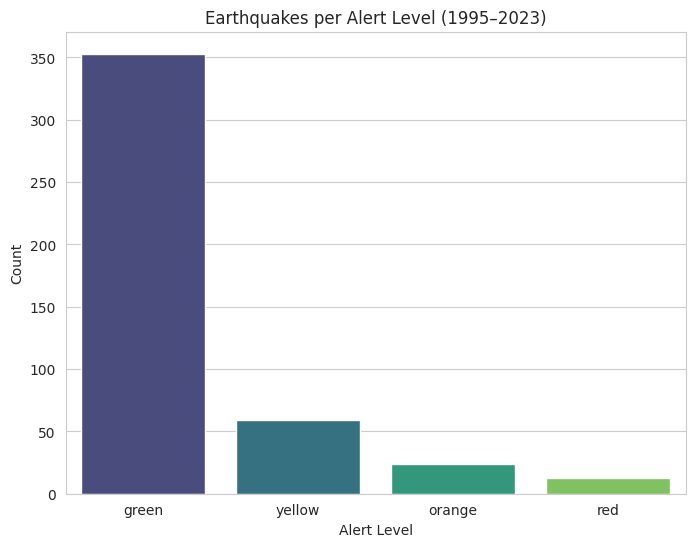

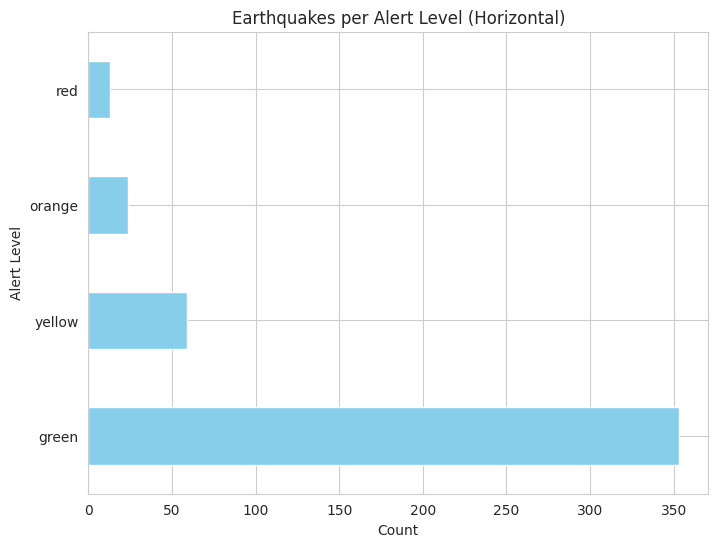

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("earthquake_1995-2023.csv")

# Bar chart: earthquakes per alert level
plt.figure(figsize=(8,6))
sns.countplot(x="alert", data=df, order=df['alert'].value_counts().index, palette="viridis")
plt.title("Earthquakes per Alert Level (1995–2023)")
plt.xlabel("Alert Level")
plt.ylabel("Count")
plt.show()

# Horizontal sorted bar
plt.figure(figsize=(8,6))
df['alert'].value_counts().plot(kind="barh", color="skyblue")
plt.title("Earthquakes per Alert Level (Horizontal)")
plt.xlabel("Count")
plt.ylabel("Alert Level")
plt.show()



Purpose: Compares counts across categories (e.g., earthquakes per alert level).

Note: Easy to see which alert level had the most earthquakes. A horizontal or sorted bar chart makes ranking clearer.

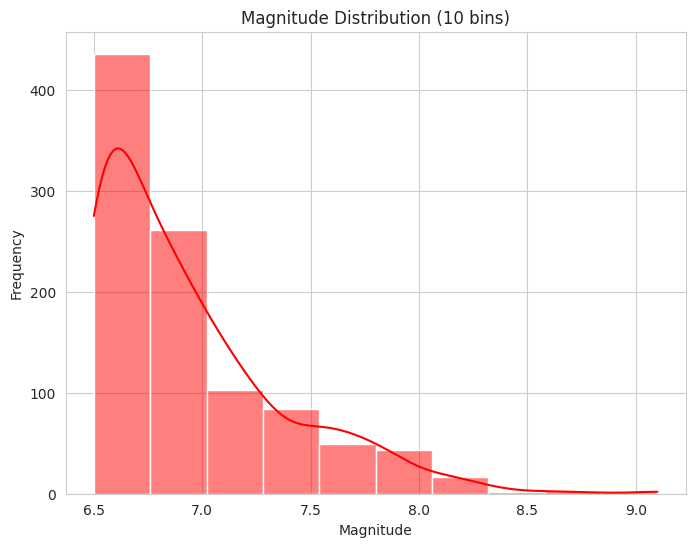

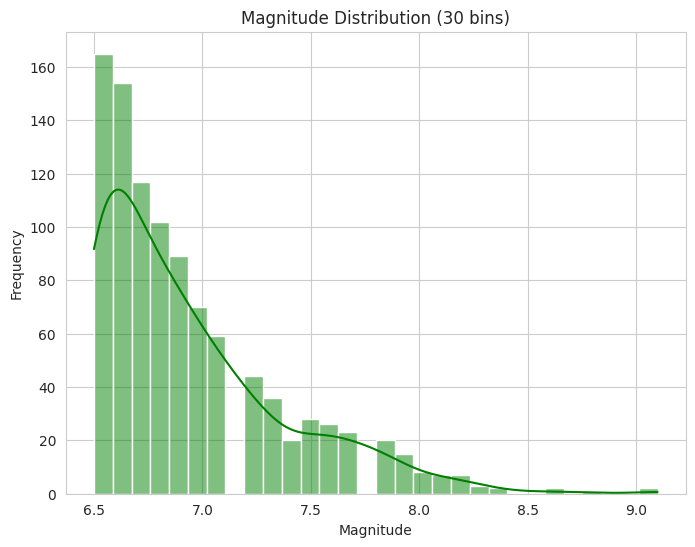

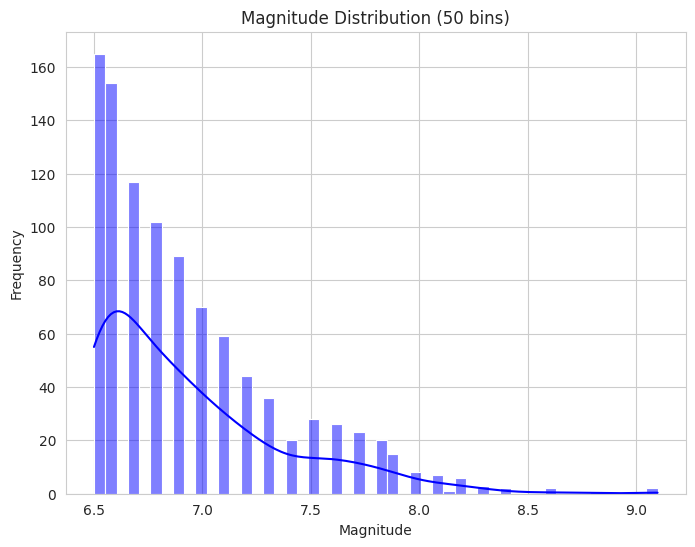

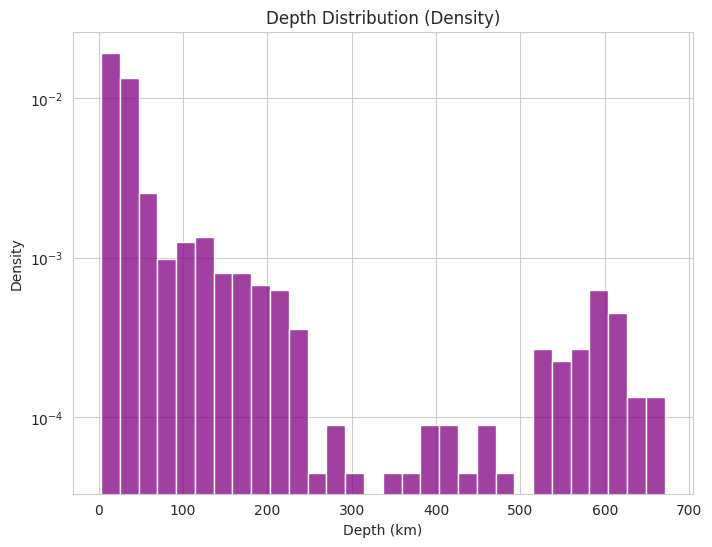

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['magnitude'], bins=10, kde=True, color="red")
plt.title("Magnitude Distribution (10 bins)")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(df['magnitude'], bins=30, kde=True, color="green")
plt.title("Magnitude Distribution (30 bins)")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(df['magnitude'], bins=50, kde=True, color="blue")
plt.title("Magnitude Distribution (50 bins)")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

# Density instead of count
plt.figure(figsize=(8,6))
sns.histplot(df['depth'], bins=30, stat="density", color="purple")
plt.title("Depth Distribution (Density)")
plt.xlabel("Depth (km)")
plt.ylabel("Density")
plt.yscale("log")  # log scale for skew
plt.show()


Purpose: Shows the distribution of a single numeric variable (e.g., magnitudes).

Note: Different bin sizes reveal different levels of detail. Fewer bins smooth the shape, while more bins expose fine structure. Density scaling or log axes help when data is skewed.

/tmp/ipykernel_1898/4246211102.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="mag_band", y="depth", data=df, palette="Set2")


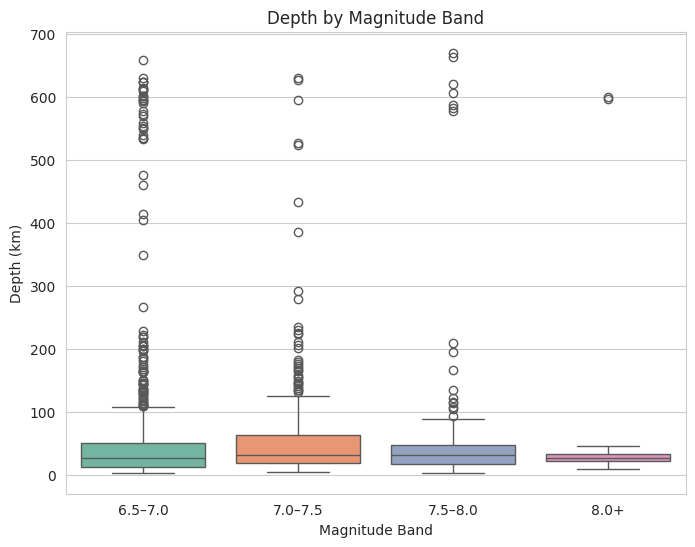

In [ ]:
df['mag_band'] = pd.cut(df['magnitude'], bins=[6.5,7,7.5,8,8.5], labels=["6.5–7.0","7.0–7.5","7.5–8.0","8.0+"])

plt.figure(figsize=(8,6))
sns.boxplot(x="mag_band", y="depth", data=df, palette="Set2")
plt.title("Depth by Magnitude Band")
plt.xlabel("Magnitude Band")
plt.ylabel("Depth (km)")
plt.show()


Purpose: Summarizes a numeric variable across groups (e.g., depth by magnitude band).

Note: The line inside the box is the median; the box shows the interquartile range; whiskers extend to typical ranges; dots are outliers. Useful for spotting differences in spread and central tendency.

/tmp/ipykernel_1898/1480229946.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="mag_band", y="depth", data=df, palette="Set3")


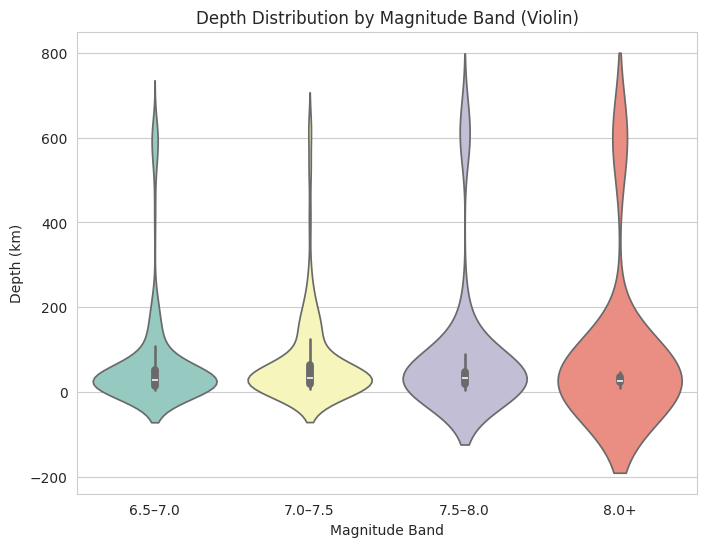

In [ ]:
plt.figure(figsize=(8,6))
sns.violinplot(x="mag_band", y="depth", data=df, palette="Set3")
plt.title("Depth Distribution by Magnitude Band (Violin)")
plt.xlabel("Magnitude Band")
plt.ylabel("Depth (km)")
plt.show()


Purpose: Same grouped comparison as the box plot, but shows the full distribution.

Note: Adds the shape of the distribution, so you can see whether values cluster, spread evenly, or have multiple peaks.

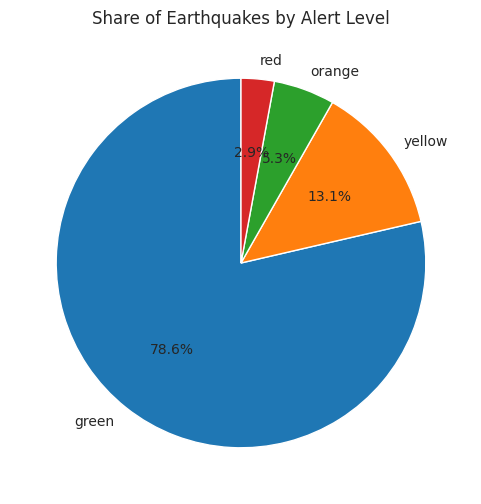

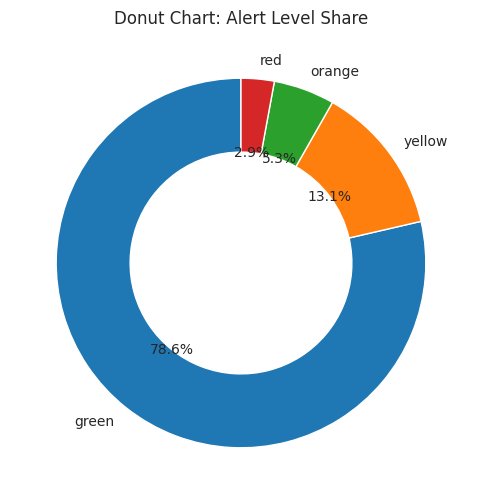

In [ ]:
alert_counts = df['alert'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(alert_counts, labels=alert_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Share of Earthquakes by Alert Level")
plt.show()

# Donut style
plt.figure(figsize=(6,6))
plt.pie(alert_counts, labels=alert_counts.index, autopct="%1.1f%%", startangle=90, wedgeprops={'width':0.4})
plt.title("Donut Chart: Alert Level Share")
plt.show()


Purpose: Shows proportions of a whole (e.g., share of alert levels).

Note: Good for small category counts, but a bar chart often communicates differences more clearly. Donut charts emphasize relative shares while leaving space in the center for labels.

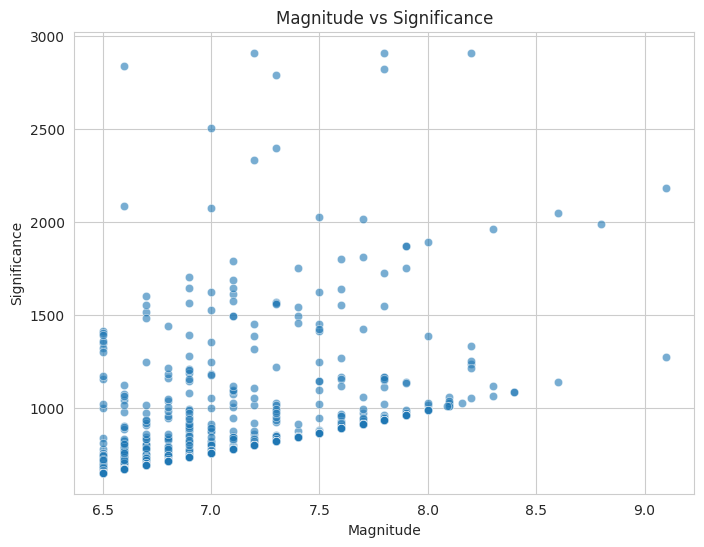

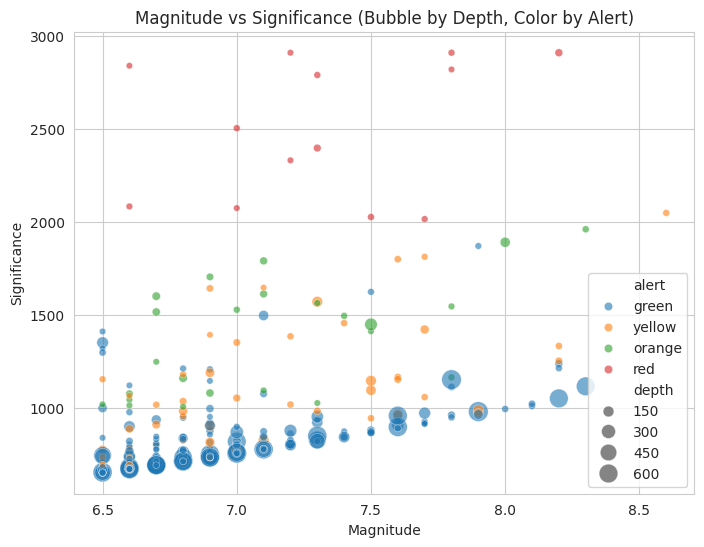

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="magnitude", y="sig", data=df, alpha=0.6)
plt.title("Magnitude vs Significance")
plt.xlabel("Magnitude")
plt.ylabel("Significance")
plt.show()

# Bubble chart: encode depth
plt.figure(figsize=(8,6))
sns.scatterplot(x="magnitude", y="sig", size="depth", hue="alert", data=df, alpha=0.6, sizes=(20,200))
plt.title("Magnitude vs Significance (Bubble by Depth, Color by Alert)")
plt.xlabel("Magnitude")
plt.ylabel("Significance")
plt.legend()
plt.show()


Purpose: Displays the relationship between two numeric variables (e.g., magnitude vs significance).

Note: Transparency helps with overlapping points. Bubble size or color adds a third dimension (e.g., depth or alert level). Useful for spotting correlations or clusters.

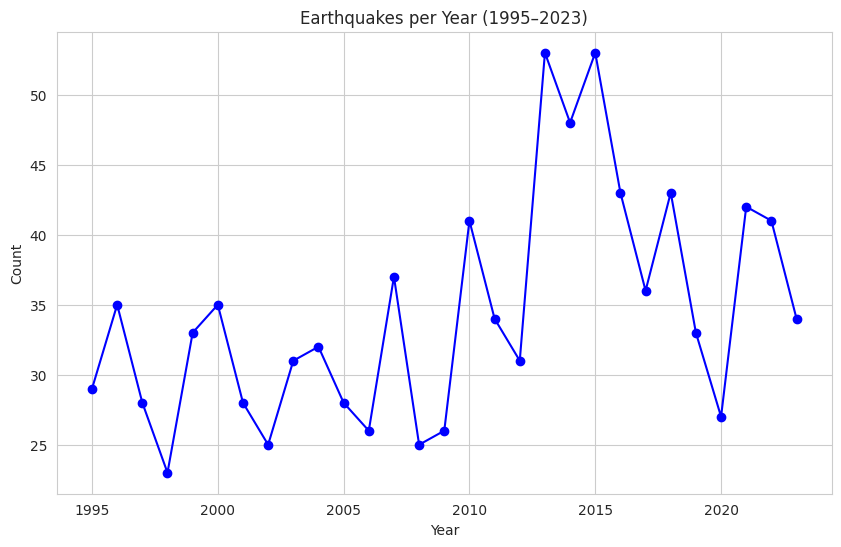

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce', dayfirst=True)
df['year'] = df['date_time'].dt.year
year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(year_counts.index, year_counts.values, marker="o", linestyle="-", color="blue")
plt.title("Earthquakes per Year (1995–2023)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


Purpose: Shows trends over time (e.g., earthquakes per year).

Note: The connected points highlight changes year by year. Markers make individual data points visible, while the line emphasizes the overall trend.

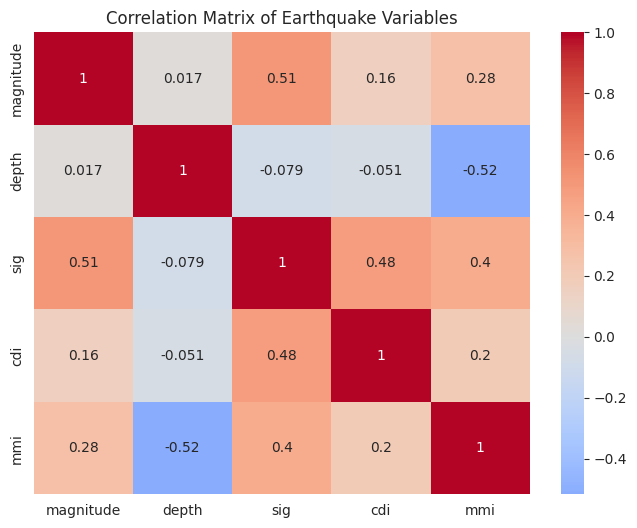

In [ ]:
corr = df[['magnitude','depth','sig','cdi','mmi']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Earthquake Variables")
plt.show()


Purpose: Displays correlations between numeric variables.

Note: Positive correlation (closer to +1) means variables rise together; negative correlation (closer to –1) means one rises while the other falls. The diverging colormap centered at zero makes direction and strength easy to read.